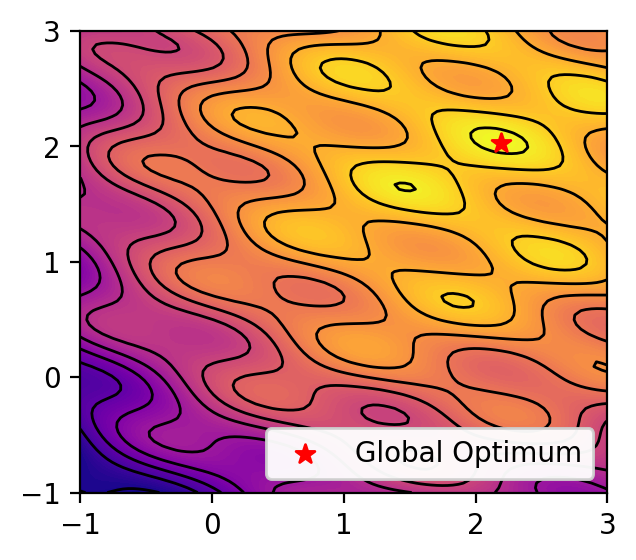

In [ ]:
import numpy as np

def f(x, y):
  return np.sin(2.5 * (x - 2 * y)) + np.cos(4.0 * (x + 2 * y)) - ((x - 2.0) ** 2 + (y - 2.0) ** 2)

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ipywidgets import interactive, widgets, Layout, interact

# add contour line
plt.rcParams['contour.negative_linestyle'] = 'solid'

class Visualizer:
  def __init__(self, func, x_lim=(-1, 3), y_lim=(-1, 3), res=100, n_contour_lines=15, quantized_values=None):
    xs = np.linspace(*x_lim, res)
    ys = np.linspace(*y_lim, res)
    self.xs, self.ys = np.meshgrid(xs, ys)
    self.zs = func(self.xs, self.ys)

    index = np.argmax(self.zs.reshape(-1))
    self.opt_x, self.opt_y = self.xs.reshape(-1)[index], self.ys.reshape(-1)[index]
    self.x_lim, self.y_lim = x_lim, y_lim

    self.n_contour_lines = n_contour_lines
    self.quantized_values = quantized_values

  def _plot_base_function(self, ax, no_bg=False, alpha=1.0, new_zs=None, new_opt=None):
    if new_zs is not None:
      zs = new_zs
    else:
      zs = self.zs
    if not no_bg:
      ctf = ax.contourf(self.xs, self.ys, zs, 100, cmap='plasma')
    ax.contour(self.xs, self.ys, zs, self.n_contour_lines, linewidths=1, colors="black", alpha=alpha)

    if self.quantized_values is not None:
      assert not no_bg
      patches = []
      for q in self.quantized_values:
        color = ctf.to_rgba(q)
        patches.append(mpatches.Patch(color=color, label=f'$f_q(x, y)={q}$'))
      legend = plt.legend(handles=patches, loc='best', ncol=3, fontsize="small")
      ax.add_artist(legend)
    else:
      if new_opt is None:
        ax.scatter(self.opt_x, self.opt_y, marker="*", s=50, color="red", label="Global Optimum", zorder=4)
      else:
        ax.scatter(self.opt_x, self.opt_y, marker="*", s=50, color="red", label="Global Optimum (Original)", zorder=4, alpha=0.75)
        ax.scatter(*new_opt, marker="*", s=50, color="darkgreen", label="Global Optimum (Smoothed)", zorder=4, alpha=0.75)

  def draw(self, ax, curves=None, no_bg=False, plot_base=True, base_alpha=1.0,
           new_zs=None, new_opt=None, legend=True):
    ax.clear()
    if plot_base:
      self._plot_base_function(ax, no_bg=no_bg, alpha=base_alpha, new_zs=new_zs, new_opt=new_opt)
    if curves is not None:
      for label, curve in curves.items():
        xs = curve["x"]
        ys = curve["y"]

        lines = []
        alphas = np.linspace(0.25, 1., len(xs) - 1)
        for x1, x2, y1, y2 in zip(xs[:-1], xs[1:], ys[:-1], ys[1:]):
            lines.extend([(x1, x2), (y1, y2)])

        ax.plot(*lines, color=curve["color"], linestyle="-", linewidth=2.0, alpha=0.25, zorder=4)
        ax.scatter(xs, ys, marker="o", facecolors='none', edgecolors=curve['color'], s=25, label=label, alpha=0.8, zorder=5)

    ax.set_xticks(np.linspace(-1., 3., 5))
    ax.set_yticks(np.linspace(-1., 3., 5))
    ax.set_xlim(*self.x_lim)
    ax.set_ylim(*self.y_lim)
    if legend:
      handles, labels = ax.get_legend_handles_labels()
      legend = plt.legend(handles=handles, labels=labels, loc='lower right')
      ax.add_artist(legend)


visualizer = Visualizer(f)

fig, ax = plt.subplots(1, 1, figsize=(3.4, 3.0), dpi=200)
visualizer.draw(ax)

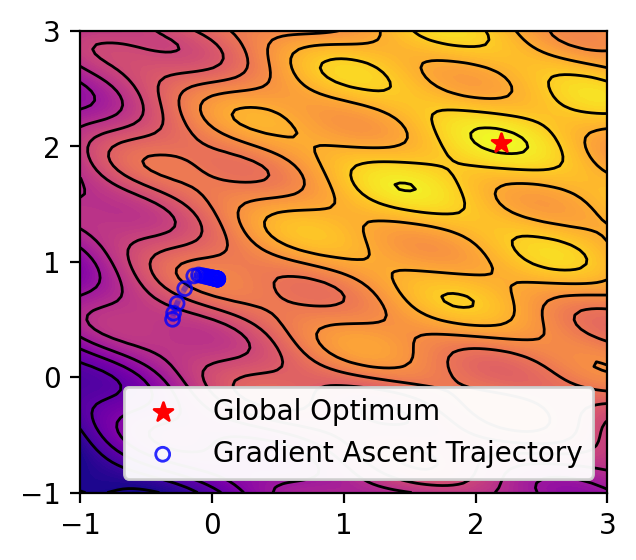

In [ ]:
def grad_f(x, y):
  dx = 2.5 * np.cos(2.5 * (x - 2 * y)) - 4.0 * np.sin(4.0 * (x + 2 * y)) - 2.0 * (x - 2.0)
  dy = -5.0 * np.cos(2.5 * (x - 2 * y)) - 8.0 * np.sin(4.0 * (x + 2 * y)) - 2.0 * (y - 2.0)
  return dx, dy

num_its = 100

def gd_step(x, y, eta):
    dx, dy = grad_f(x, y)  # Compute the gradient of f
    new_x = x + eta * dx  # Update x in the direction of the gradient
    new_y = y + eta * dy  # Update y in the direction of the gradient
    return new_x, new_y

num_its = 30      # number of gradient steps
eta = 0.01        # learning rate
x, y = -0.3, 0.5  # initial parameter values (CHANGE ME!)

# history of parameter values
xs = [x]
ys = [y]

for i in range(num_its):
    x, y = gd_step(x, y, eta)
    xs.append(x)
    ys.append(y)

fig, ax = plt.subplots(1, 1, figsize=(3.4, 3.0), dpi=200)
visualizer.draw(ax, {f"Gradient Ascent Trajectory": {"color": "blue", "x": xs, "y": ys}})

In [ ]:
# we put all points that are less than eps apart (Euclidean distance) together.
def manual_clustering(t_xs, t_ys, max_num_clusters=23, eps=1e-2):
  labels = np.zeros_like(t_xs, dtype=int)

  codebook = []
  while True:
    unlabeled_indx, unlabeled_indy = np.nonzero(labels == 0)
    if len(unlabeled_indx) == 0 or len(codebook) > max_num_clusters: break

    first = (unlabeled_indx[0], unlabeled_indy[0])
    codebook.append(np.array([t_xs[first], t_ys[first]]))

    matched = (t_xs[first] - t_xs) ** 2 + (t_ys[first] - t_ys) ** 2 <= eps * eps
    labels[matched] = len(codebook)

  # codebook stores an array of representative point in the cluster
  # labels stores an array of index that represents which cluster each example belongs to
  return np.stack(codebook), labels

# generate a grid of initialization points
t_xs, t_ys = np.linspace(-1, 3, 100), np.linspace(-1, 3, 100)
t_xs, t_ys = np.meshgrid(t_xs, t_ys)
num_its = 1000

# run gradient ascent
t_xs_history, t_ys_history = [t_xs], [t_ys]
for i in range(num_its):
    t_xs, t_ys = gd_step(t_xs, t_ys, 0.01)
    t_xs_history.append(t_xs)
    t_ys_history.append(t_ys)

# cluster them based on the final parameter values
codebook, labels = manual_clustering(t_xs, t_ys)

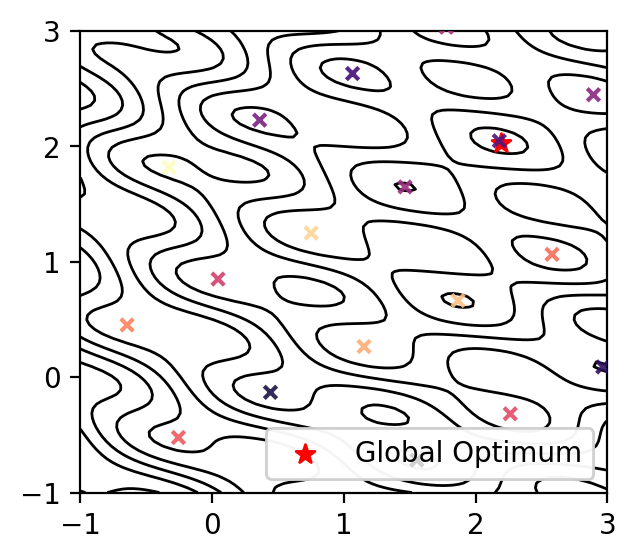

In [ ]:
import random
cmap = matplotlib.colormaps['magma']
colors = [cmap(x) for x in np.linspace(0, 1.0, len(codebook) + 1)]
random.seed(2)
random.shuffle(colors)
colors = np.array(colors)

fig, ax = plt.subplots(1, 1, figsize=(3.4, 3), dpi=200)
visualizer.draw(ax, no_bg=True)
ax.scatter(codebook[:, 0], codebook[:, 1], color=colors[:-1], alpha=0.9, s=20, marker="x", zorder=5)

In [ ]:
def update_images(i):
  fig, ax = plt.subplots(1, 1, figsize=(3.4, 3), dpi=200)
  ax.set_facecolor('lightgray')
  visualizer.draw(ax, no_bg=True)
  ax.scatter(t_xs_history[i].reshape(-1), t_ys_history[i].reshape(-1), facecolors='none', edgecolors=colors[labels.reshape(-1)], alpha=0.3, s=20, marker="o", zorder=5)
  plt.show()

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=100,
    description="# of gd steps"
)
interact(update_images, i=slider)

interactive(children=(IntSlider(value=0, description='# of gd steps'), Output()), _dom_classes=('widget-intera…

<function __main__.update_images(i)>

In [ ]:
import matplotlib
from functools import partial

cmap = matplotlib.colormaps['ocean']
seed = 1437

rng = np.random.default_rng(seed=seed)
num_its = 15
num_inits = 3
init_xs, init_ys = rng.random(num_inits) * 0.9, rng.random(num_inits) * 1.2
colors = [cmap(x) for x in np.linspace(0, 0.6, num_inits)]

def generate_curves(eta, optimizer, num_its, num_inits):
  xs, ys = np.empty((num_its + 1, num_inits)), np.empty((num_its + 1, num_inits))
  xs[0], ys[0] = init_xs, init_ys
  for i in range(1, num_its + 1):
    xs[i], ys[i] = optimizer(xs[i-1], ys[i-1], eta)

  curves = {}
  for i in range(num_inits):
    curves[f"Trajectory (Init #{i+1})"] = {"color": colors[i], "x": xs[:, i], "y": ys[:, i]}
  return curves


def get_interactive(visualizer, ax, gen_fn):

  def update_images(eta):
    fig, ax = plt.subplots(1, 1, figsize=(4.0, 4.0), dpi=200)
    curves = gen_fn(eta)
    visualizer.draw(ax, curves)

  slider = widgets.FloatLogSlider(
      value=0.001,
      base=10,
      min=-3, # min exponent of base
      max=-1, # max exponent of base
      step=0.2, # exponent step
      description='eta'
  )
  return interactive(update_images, eta=slider)

ip = get_interactive(visualizer, ax, partial(generate_curves, optimizer=gd_step, num_its=num_its, num_inits=num_inits))
ip

interactive(children=(FloatLogSlider(value=0.001, description='eta', max=-1.0, min=-3.0, step=0.2), Output()),…

In [ ]:

def f(x, y):
    return 2.5 * np.cos(2.5 * (x - 2 * y)) - 4.0 * np.sin(4.0 * (x + 2 * y)) + (x - 2.0)**2 + (y - 2.0)**2

# Smoothed function using Monte Carlo
def smoothed_f(x, y, sigma, N):
    """
    Estimate the smoothed function value using Monte Carlo integration.

    Args:
    - x: the current x parameter
    - y: the current y parameter
    - sigma: the standard deviation for the Gaussian noise
    - N: the number of samples to use for averaging

    Returns:
    - The estimated smoothed function value
    """
    total = 0
    for _ in range(N):
        # Generate random perturbations
        perturb_x = np.random.normal(0, sigma)
        perturb_y = np.random.normal(0, sigma)

        # Evaluate the function at the perturbed point
        total += f(x + perturb_x, y + perturb_y)

    # Average over all samples
    return total / N

# Example usage:
x, y = 1.0, 2.0  # some example values for x and y
sigma = 0.1       # standard deviation for noise
N = 1000          # number of Monte Carlo samples

smoothed_value = smoothed_f(x, y, sigma, N)
print(f"Smoothed function value: {smoothed_value}")


Smoothed function value: -0.560487748051072


In [ ]:
zs_dict = {}
opt_dict = {}
for sigma in [0.01, 0.1, 0.2, 0.3, 0.5]:
  zs = []
  xs, ys = visualizer.xs, visualizer.ys
  for x, y in zip(xs.reshape(-1), ys.reshape(-1)):
    zs.append(smoothed_f(x, y, sigma, N=10000))
  zs_dict[sigma] = np.array(zs).reshape(xs.shape)
  index = np.argmax(zs_dict[sigma].reshape(-1))
  opt_dict[sigma] = (xs.reshape(-1)[index], ys.reshape(-1)[index])

KeyboardInterrupt: 

interactive(children=(SelectionSlider(continuous_update=False, description='sigma', options=(0.01, 0.1, 0.2, 0…

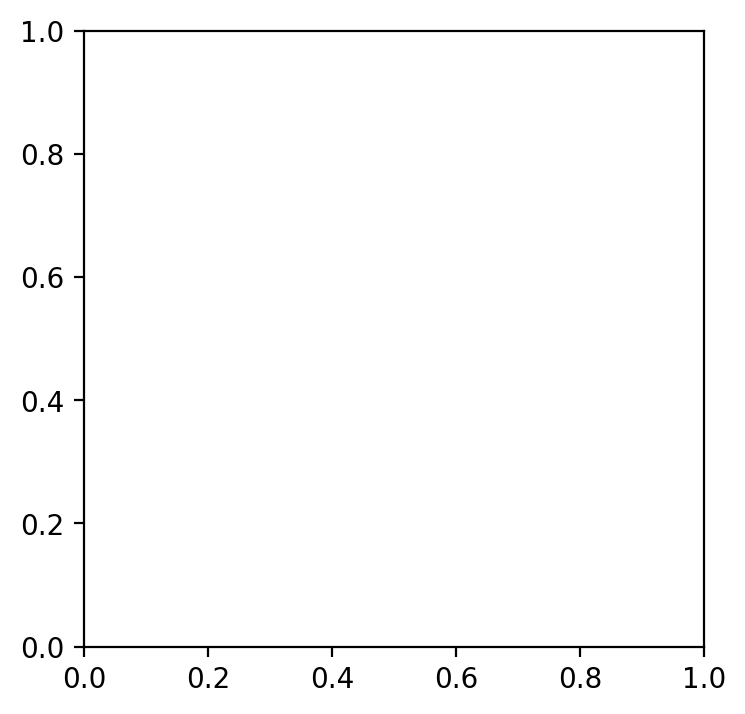

In [ ]:
def update_images(sigma):
  fig, ax = plt.subplots(1, 1, figsize=(4.0, 4.0), dpi=200)
  xs, ys = visualizer.xs, visualizer.ys
  zs = zs_dict[sigma]
  ax.contourf(xs, ys, zs, 50, cmap='plasma')
  ax.contour(xs, ys, zs, 15, linewidths=1, colors="black")

  ax.scatter(visualizer.opt_x, visualizer.opt_y, marker="*", s=50, color="red", label="Global Optimum (Original)", alpha=0.5, zorder=4)
  ax.scatter(*opt_dict[sigma], marker="*", s=50, color="darkgreen", label="Global Optimum (Smoothed)", alpha=0.5, zorder=4)
  ax.legend()

slider = widgets.SelectionSlider(
    options=[0.01, 0.1, 0.2, 0.3, 0.5],
    value=0.01,
    description='sigma',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True
)
interactive(update_images, sigma=slider)

KeyError: 0.3

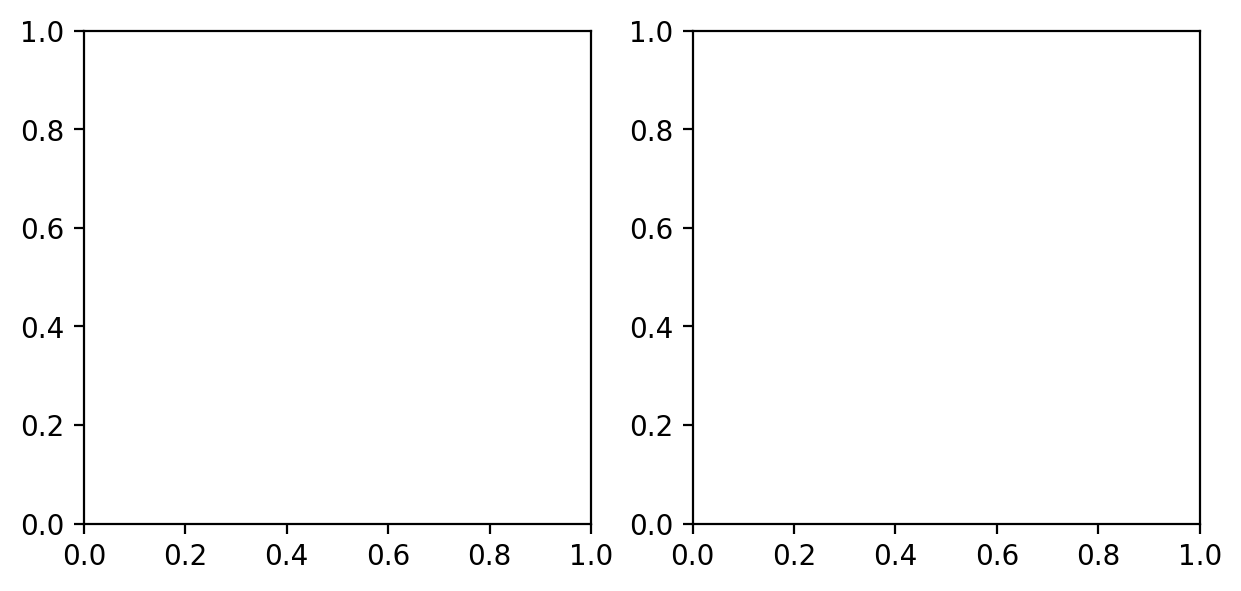

In [ ]:
def finite_diff_grad_step(x, y, delta, N, eta, sigma):
    tx = np.random.normal(x, sigma, size=(N,))
    ty = np.random.normal(y, sigma, size=(N,))

    grad_x = 0.0
    grad_y = 0.0

    for i in range(N):
        # finite difference in x
        f_plus = f(tx[i] + delta, ty[i])
        f_minus = f(tx[i] - delta, ty[i])
        grad_x += (f_plus - f_minus) / (2 * delta)

        # finite difference in y
        f_plus = f(tx[i], ty[i] + delta)
        f_minus = f(tx[i], ty[i] - delta)
        grad_y += (f_plus - f_minus) / (2 * delta)

    # Average the gradients over the N samples
    grad_x /= N
    grad_y /= N

    # Gradient descent step
    new_x = x - eta * grad_x
    new_y = y - eta * grad_y

    return new_x, new_y


num_its = 30      # number of gradient steps
eta = 0.1         # learning rate
delta = 0.25      # finite difference magnitude
N = 20            # number of samples for MC estimation
sigma = 0.3       # the magnitude of the Gaussian noise.
x, y = -0.3, 0.5  # initial parameter values

# history of parameter values
xs = [x]
ys = [y]

for i in range(num_its):
    x, y = finite_diff_grad_step(x, y, delta, N, eta, sigma)
    xs.append(x)
    ys.append(y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3.2), dpi=200)
visualizer.draw(ax1, {f"FD Trajectory": {"color": "blue", "x": xs, "y": ys}}, new_opt=opt_dict[sigma], legend=False)
visualizer.draw(ax2, {f"FD Trajectory": {"color": "blue", "x": xs, "y": ys}}, new_zs=zs_dict[sigma], new_opt=opt_dict[sigma], legend=False)

ax1.set_title("Original ($f$)")
ax2.set_title("Smoothed ($f_\sigma$)")
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.08))

interactive(children=(SelectionSlider(continuous_update=False, description='N', index=4, options=(1, 2, 5, 10,…

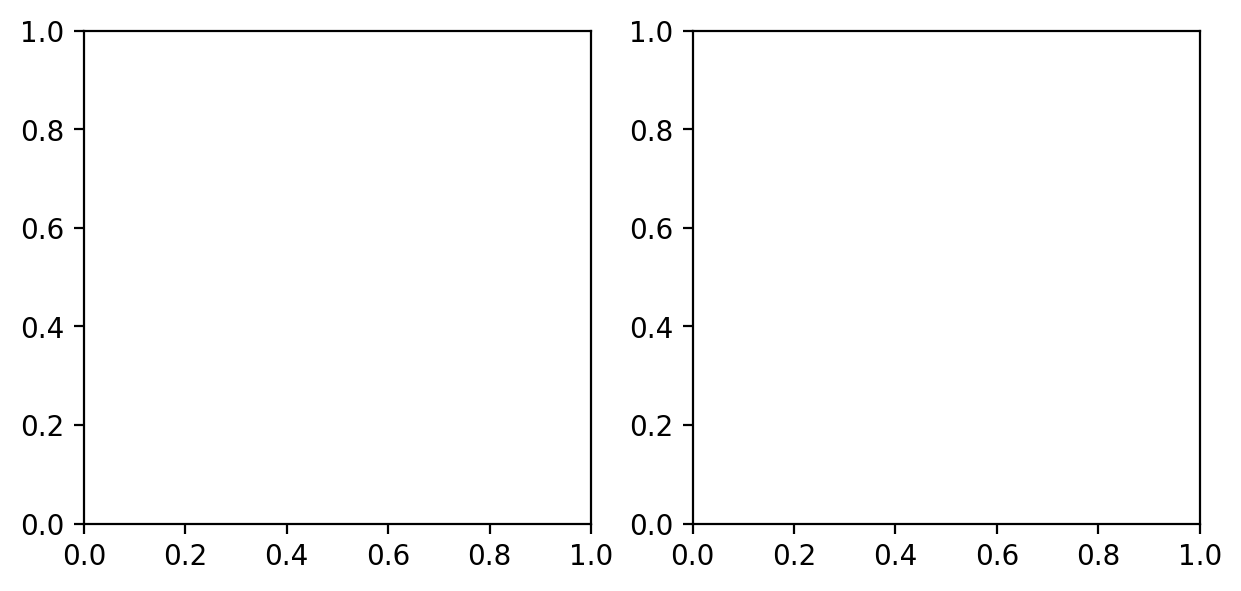

In [ ]:
def get_interactive(grad_step_fn, label_name, init_x=-0.3, init_y=0.5, num_its=30, has_delta=False):

  def generate_curves(*args, **kwargs):
    x, y = init_x, init_y
    xs, ys = [init_x], [init_y]
    for i in range(1, num_its + 1):
      x, y = grad_step_fn(x, y, *args, **kwargs)
      xs.append(x)
      ys.append(y)

    return {label_name: {"color": "blue", "x": xs, "y": ys}}

  def update_images(*args, **kwargs):
    sigma=0.3
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3.2), dpi=200)
    curves = generate_curves(*args, **kwargs, sigma=sigma)

    visualizer.draw(ax1, curves, new_opt=opt_dict[sigma], legend=False)
    visualizer.draw(ax2, curves, new_zs=zs_dict[sigma], new_opt=opt_dict[sigma], legend=False)

    ax1.set_title("Original ($f$)")
    ax2.set_title("Smoothed ($f_\sigma$)")
    handles, labels = ax2.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.08))
    plt.show()

  eta_slider = widgets.FloatLogSlider(
      value=0.1,
      base=10,
      min=-3, # min exponent of base
      max=0, # max exponent of base
      step=0.2, # exponent step
      description='eta'
  )

  N_slider = widgets.SelectionSlider(
      options=[1, 2, 5, 10, 20, 50, 100],
      value=20,
      description='N',
      disabled=False,
      continuous_update=False,
      orientation='horizontal',
      readout=True
  )
  if has_delta:
    delta_slider = widgets.FloatLogSlider(
        value=0.3,
        base=10,
        min=-3, # min exponent of base
        max=0, # max exponent of base
        step=0.2, # exponent step
        description='delta'
    )
    return interactive(update_images, N=N_slider, eta=eta_slider, delta=delta_slider)
  return interactive(update_images, N=N_slider, eta=eta_slider)

get_interactive(finite_diff_grad_step, "FD Trajectory", has_delta=True)

KeyError: 0.3

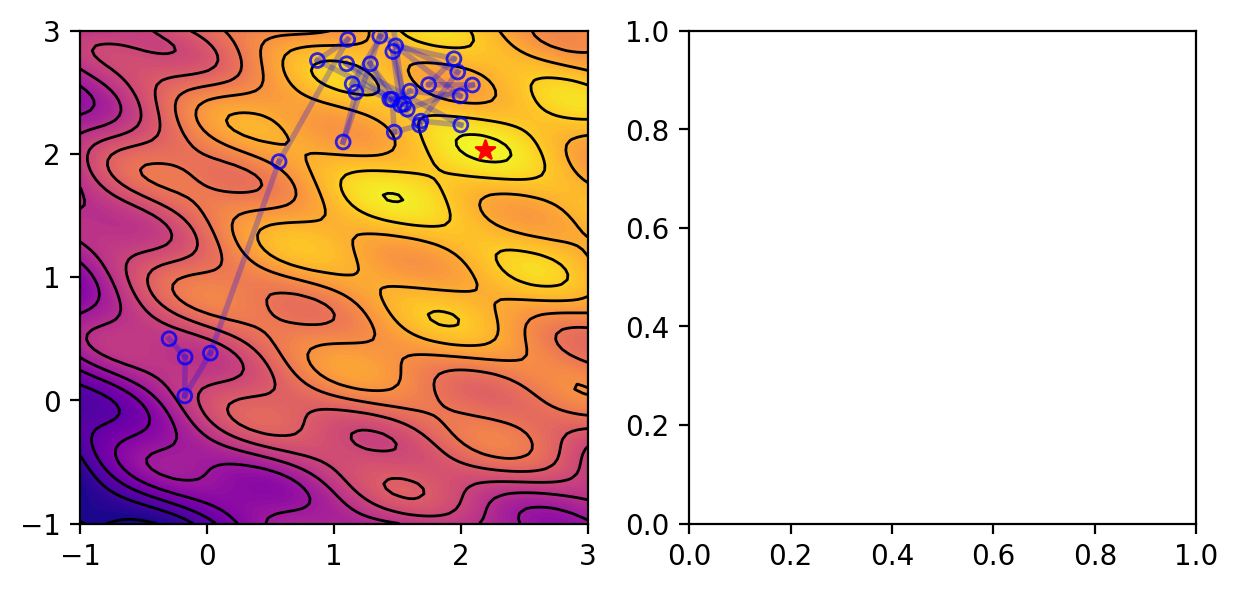

In [ ]:
def pg_grad_step(x, y, N, eta, sigma):
    tx = np.random.normal(x, sigma, size=N)  # noisy samples for x
    ty = np.random.normal(y, sigma, size=N)  # noisy samples for y

    grad_x = 0.0
    grad_y = 0.0

    for i in range(N):
        fx = f(tx[i], ty[i])  # function at noisy sample
        grad_x += fx * (tx[i] - x) / (sigma ** 2)
        grad_y += fx * (ty[i] - y) / (sigma ** 2)

    # Average the gradients
    grad_x /= N
    grad_y /= N
    new_x = x - eta * grad_x
    new_y = y - eta * grad_y

    return new_x, new_y


num_its = 30      # number of gradient steps
eta = 0.1         # learning rate
N = 20            # number of samples for MC estimation
sigma = 0.3       # the magnitude of the Gaussian noise
x, y = -0.3, 0.5  # initial parameter values

# history of parameter values
xs = [x]
ys = [y]

for i in range(num_its):
    x, y = pg_grad_step(x, y, N, eta, sigma)
    xs.append(x)
    ys.append(y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3.2), dpi=200)
visualizer.draw(ax1, {f"PG Trajectory": {"color": "blue", "x": xs, "y": ys}}, legend=False)
visualizer.draw(ax2, {f"PG Trajectory": {"color": "blue", "x": xs, "y": ys}}, new_zs=zs_dict[sigma], legend=False)

ax1.set_title("Original ($f$)")
ax2.set_title("Smoothed ($f_\sigma$)")
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.08))
pass

interactive(children=(SelectionSlider(continuous_update=False, description='N', index=4, options=(1, 2, 5, 10,…

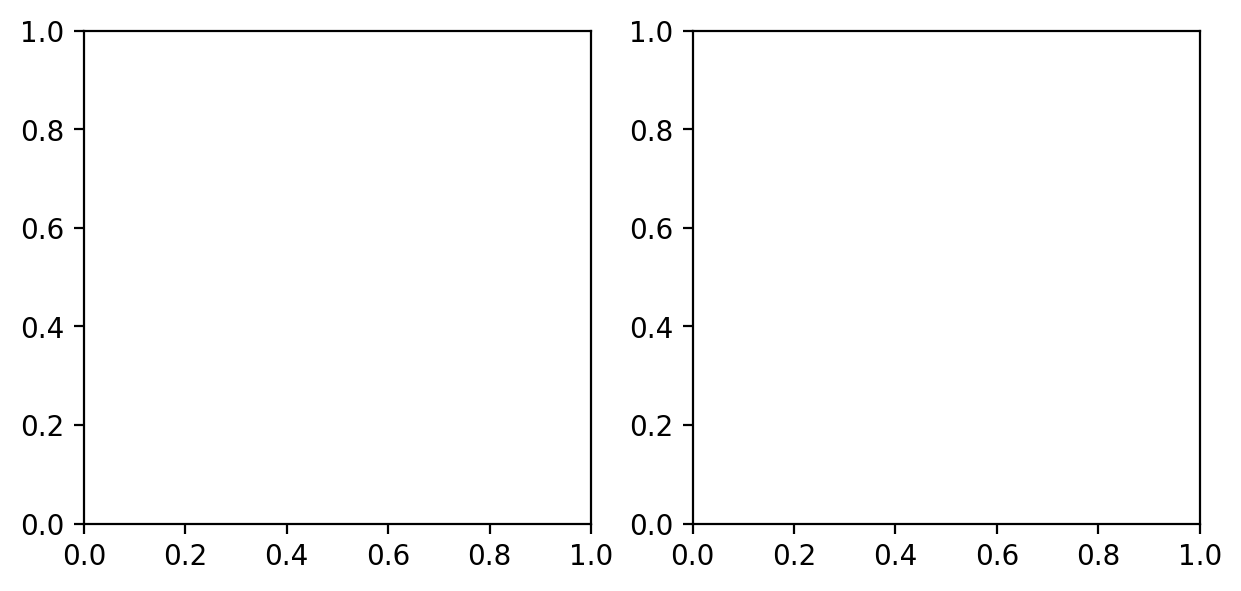

In [ ]:
get_interactive(pg_grad_step, "PG Trajectory", has_delta=False)

KeyError: 0.3

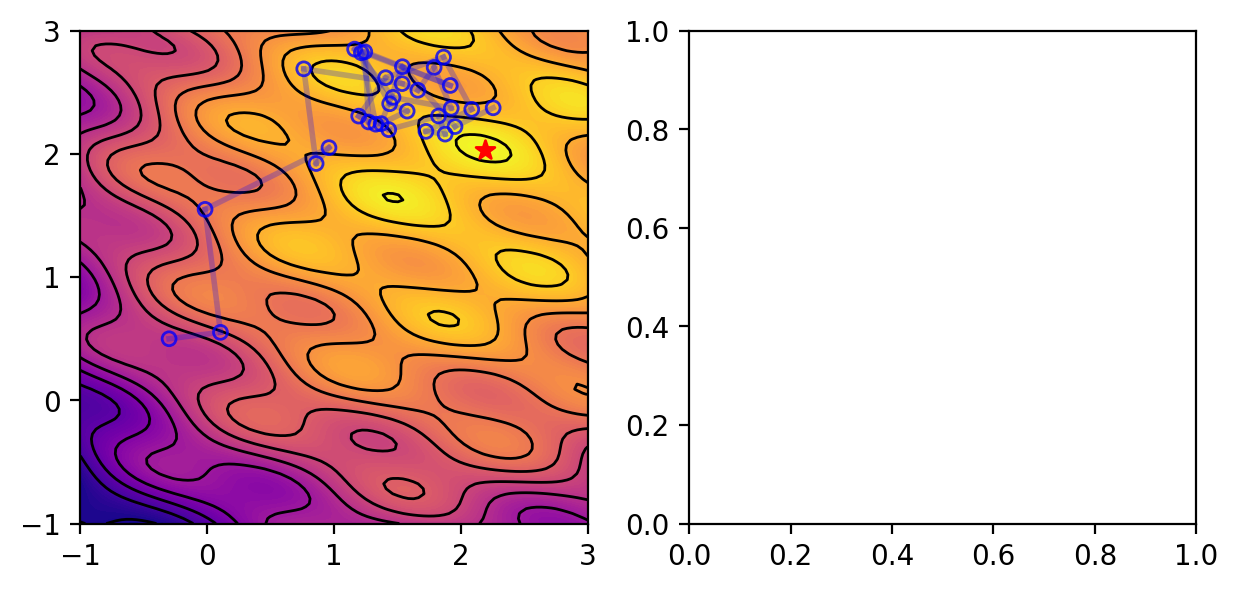

In [ ]:
def reparam_grad_step(x, y, N, eta, sigma):
    eps_x = np.random.normal(0, 1, size=N)  # standard normal samples
    eps_y = np.random.normal(0, 1, size=N)

    tx = x + sigma * eps_x  # reparameterized samples for x
    ty = y + sigma * eps_y  # reparameterized samples for y

    grad_x = 0.0
    grad_y = 0.0

    for i in range(N):
        fx = f(tx[i], ty[i])

        grad_x += fx * eps_x[i]
        grad_y += fx * eps_y[i]

    grad_x *= 1.0 / (N * sigma)
    grad_y *= 1.0 / (N * sigma)

    new_x = x - eta * grad_x
    new_y = y - eta * grad_y

    return new_x, new_y

num_its = 30      # number of gradient steps
eta = 0.1         # learning rate
N = 20            # number of samples for MC estimation
sigma = 0.3       # the magnitude of the Gaussian noise
x, y = -0.3, 0.5  # initial parameter values

# history of parameter values
xs = [x]
ys = [y]

for i in range(num_its):
    x, y = pg_grad_step(x, y, N, eta, sigma)
    xs.append(x)
    ys.append(y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3.2), dpi=200)
visualizer.draw(ax1, {f"Reparam Trajectory": {"color": "blue", "x": xs, "y": ys}}, legend=False)
visualizer.draw(ax2, {f"Reparam Trajectory": {"color": "blue", "x": xs, "y": ys}}, new_zs=zs_dict[sigma], legend=False)

ax1.set_title("Original ($f$)")
ax2.set_title("Smoothed ($f_\sigma$)")
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.08))
pass